In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import numpy as np
import observe
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
colors = {
    "zfp.rs": mpl.cm.tab10.colors[0],
    "sz3.rs": mpl.cm.tab10.colors[6],
    "sperr.rs": mpl.cm.tab10.colors[2],
}

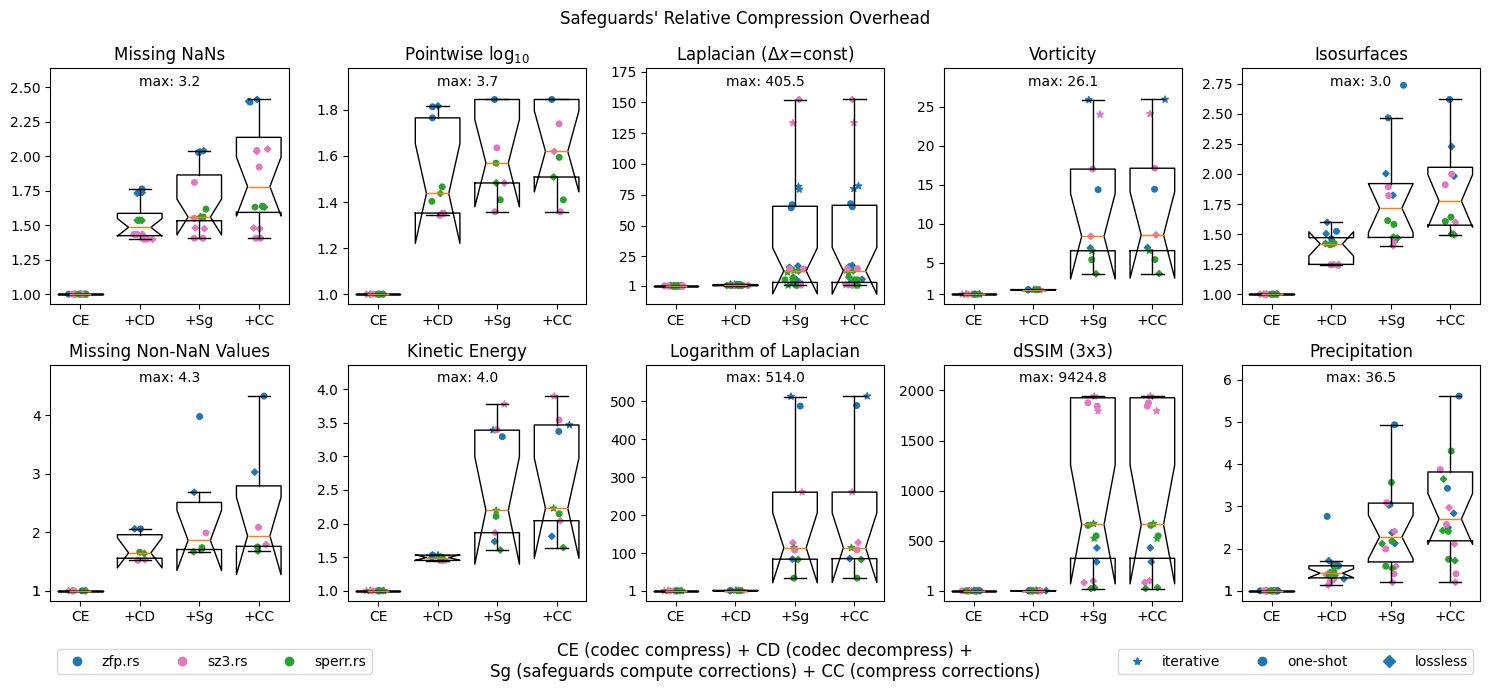

In [3]:
fig = plt.figure(layout="tight", figsize=(15, 7))
gs = GridSpec(3, 5, figure=fig, height_ratios=[1, 1, 0.0])

for i, (name, title) in enumerate(
    {
        "nan.json": "Missing NaNs",
        "missing.json": "Missing Non-NaN Values",
        "specific-humidity-log10.json": r"Pointwise $\log_{10}$",
        "kinetic-energy.json": "Kinetic Energy",
        "derivative-radial.json": r"Laplacian ($\Delta x$=const)",
        "derivative-log-exp.json": "Logarithm of Laplacian",
        "vorticity.json": "Vorticity",
        "dssim.json": "dSSIM (3x3)",
        "isosurface.json": "Isosurfaces",
        "precipitation.json": "Precipitation",
    }.items()
):
    with Path("observations").joinpath(name).open() as f:
        observations = json.load(f)

    scatter_colors = []
    is_iteratives = []
    is_losslesss = []
    codec_encode_timings = []
    codec_decode_timings = []
    corrections_compute_timings = []
    corrections_encode_timings = []

    for result in observations:
        if result["codec"]["id"] != "safeguards":
            continue

        codec_id = result["codec"]["codec"]["id"]

        if codec_id == "combinators.stack":
            a, b = result["codec"]["codec"]["codecs"]
            assert a["id"] == "replace.filter", a["id"]
            codec_id = b["id"]
        elif codec_id == "pw_ratio":
            codec_id = result["codec"]["codec"]["log_codec"]["id"]

        assert codec_id in ["zero", "zfp.rs", "sz3.rs", "sperr.rs"], codec_id

        if codec_id == "zero":
            continue

        is_iterative = result["codec"]["compute"]["unstable_iterative"]
        is_lossless = result["codec"]["compute"]["unstable_lossless_corrections"]

        assert result["codec"]["lossless"]["for_codec"] is None

        (safeguarded_encode_timing,) = result["encode_timing"][
            observe.json_hash(result["codec"])
        ]
        (codec_encode_encode_timing,) = result["encode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        codec_encode_decode_timing, codec_decode_timing = result["decode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        # corrections lossless codec may be skipped if no corrections are needed
        (lossless_for_corrections_encode_timing,) = result["encode_timing"].get(
            observe.json_hash(result["codec"]["lossless"]["for_corrections"]), [0]
        )

        (safeguarded_decode_timing,) = result["decode_timing"][
            observe.json_hash(result["codec"])
        ]
        # corrections lossless codec may be skipped if no corrections are needed
        (lossless_for_corrections_decode_timing,) = result["decode_timing"].get(
            observe.json_hash(result["codec"]["lossless"]["for_corrections"]), [0]
        )

        scatter_colors.append(colors[codec_id])
        is_iteratives.append(is_iterative and not is_lossless)
        is_losslesss.append(is_iterative and is_lossless)
        codec_encode_timings.append(
            codec_encode_encode_timing / codec_encode_encode_timing
        )
        codec_decode_timings.append(
            codec_encode_decode_timing / codec_encode_encode_timing
        )
        corrections_compute_timings.append(
            lossless_for_corrections_encode_timing / codec_encode_encode_timing
        )
        corrections_encode_timings.append(
            (
                safeguarded_encode_timing
                - codec_encode_encode_timing
                - codec_encode_decode_timing
                - lossless_for_corrections_encode_timing
            )
            / codec_encode_encode_timing
        )

    is_losslesss = np.array(is_losslesss)
    is_iteratives = np.array(is_iteratives)

    ax = fig.add_subplot(gs[i % 2, i // 2])

    ax.set_title(title)

    rng = np.random.default_rng(seed=42)

    b1 = ax.boxplot(codec_encode_timings, notch=True, showfliers=False, positions=[0])
    b2 = ax.boxplot(
        np.array(codec_decode_timings) + np.array(codec_encode_timings),
        notch=True,
        showfliers=False,
        positions=[0.2],
    )
    b3 = ax.boxplot(
        np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings),
        notch=True,
        showfliers=False,
        positions=[0.4],
    )
    b4 = ax.boxplot(
        np.array(corrections_compute_timings)
        + np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings),
        notch=True,
        showfliers=False,
        positions=[0.6],
    )

    extra = (ax.get_ylim()[1] - ax.get_ylim()[0]) / 10

    ax.set_xlim(-0.1, 0.7)
    ax.set_xticklabels(["CE", "+CD", "+Sg", "+CC"])
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + extra)
    ax.set_yticks(
        [
            1 if y == 0 else y
            for y in ax.get_yticks()
            if (y >= 1 and y <= ax.get_ylim()[1]) or y == 0
        ]
    )

    ax.text(
        0.3,
        b4["caps"][1].get_data()[1][0] + extra / 2,
        f"max: {np.round(np.amax(corrections_compute_timings) + np.amax(corrections_encode_timings) + np.amax(codec_decode_timings) + np.amax(codec_encode_timings), 1)}",
        ha="center",
        va="bottom",
    )

    cs = np.array(scatter_colors)

    xs = rng.normal(loc=0.0, scale=0.1 / 5, size=len(codec_encode_timings))
    ys = np.array(codec_encode_timings)
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.2, scale=0.1 / 5, size=len(codec_decode_timings))
    ys = np.array(codec_decode_timings) + np.array(codec_encode_timings)
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.4, scale=0.1 / 5, size=len(corrections_encode_timings))
    ys = (
        np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings)
    )
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.6, scale=0.1 / 5, size=len(corrections_compute_timings))
    ys = (
        np.array(corrections_compute_timings)
        + np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings)
    )
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

fig.suptitle("Safeguards' Relative Compression Overhead")

ax = fig.add_subplot(gs[2, :])
ax.axis("off")
l1 = ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=col,
            markeredgecolor=col,
            label=c,
        )
        for c, col in colors.items()
    ],
    ncol=3,
    loc="center left",
)
ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            marker="*",
            color="none",
            markerfacecolor=colors["zfp.rs"],
            markeredgecolor=colors["zfp.rs"],
            label="iterative",
        ),
        mpl.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=colors["zfp.rs"],
            markeredgecolor=colors["zfp.rs"],
            label="one-shot",
        ),
        mpl.lines.Line2D(
            [0],
            [0],
            marker="D",
            color="none",
            markerfacecolor=colors["zfp.rs"],
            markeredgecolor=colors["zfp.rs"],
            label="lossless",
        ),
    ],
    ncol=3,
    loc="center right",
)
ax.add_artist(l1)
ax.text(
    0.5,
    0.5,
    "CE (codec compress) + CD (codec decompress) +\nSg (safeguards compute corrections) + CC (compress corrections)",
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize="large",
)

plt.tight_layout()

plt.savefig(Path("plots") / "overhead-compression.pdf", dpi=300)

plt.show()

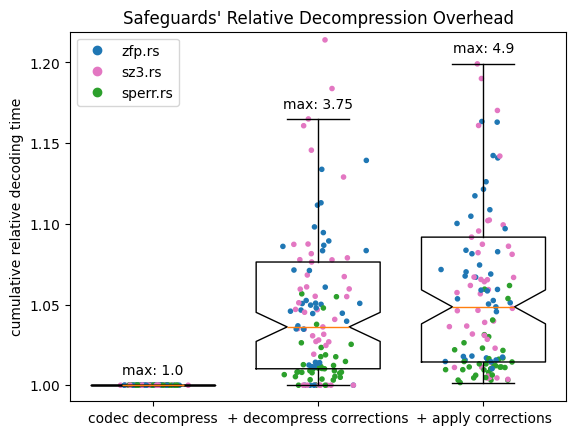

In [4]:
fig, ax = plt.subplots()

rng = np.random.default_rng(seed=42)

ax.set_title("Safeguards' Relative Decompression Overhead")

scatter_colors = []
codec_decode_timings = []
corrections_decode_timings = []
corrections_apply_timings = []

for name in [
    "derivative-log-exp.json",
    "derivative-radial.json",
    "dssim.json",
    "isosurface.json",
    "kinetic-energy.json",
    "missing.json",
    "nan.json",
    "precipitation.json",
    "specific-humidity-log10.json",
    "vorticity.json",
]:
    with Path("observations").joinpath(name).open() as f:
        observations = json.load(f)

    for result in observations:
        if result["codec"]["id"] != "safeguards":
            continue

        codec_id = result["codec"]["codec"]["id"]

        if codec_id == "combinators.stack":
            a, b = result["codec"]["codec"]["codecs"]
            assert a["id"] == "replace.filter", a["id"]
            codec_id = b["id"]
        elif codec_id == "pw_ratio":
            codec_id = result["codec"]["codec"]["log_codec"]["id"]

        assert codec_id in ["zero", "zfp.rs", "sz3.rs", "sperr.rs"], codec_id

        if codec_id == "zero":
            continue

        assert result["codec"]["lossless"]["for_codec"] is None

        codec_encode_decode_timing, codec_decode_timing = result["decode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        (safeguarded_decode_timing,) = result["decode_timing"][
            observe.json_hash(result["codec"])
        ]
        # corrections lossless codec may be skipped if no corrections are needed
        (lossless_for_corrections_decode_timing,) = result["decode_timing"].get(
            observe.json_hash(result["codec"]["lossless"]["for_corrections"]), [0]
        )

        scatter_colors.append(colors[codec_id])
        codec_decode_timings.append(codec_decode_timing / codec_decode_timing)
        corrections_decode_timings.append(
            lossless_for_corrections_decode_timing / codec_decode_timing
        )
        corrections_apply_timings.append(
            (
                safeguarded_decode_timing
                - codec_decode_timing
                - lossless_for_corrections_decode_timing
            )
            / codec_decode_timing
        )

b = ax.boxplot(codec_decode_timings, notch=True, showfliers=False, positions=[0])
ax.text(
    0,
    b["caps"][1].get_data()[1][0] + 0.005,
    f"max: {np.amax(codec_decode_timings)}",
    ha="center",
    va="bottom",
)
b = ax.boxplot(
    np.array(corrections_decode_timings) + np.array(codec_decode_timings),
    notch=True,
    showfliers=False,
    positions=[0.2],
)
ax.text(
    0.2,
    b["caps"][1].get_data()[1][0] + 0.005,
    f"max: {np.amax(corrections_decode_timings) + np.amax(codec_decode_timings):0.3}",
    ha="center",
    va="bottom",
)
b = ax.boxplot(
    np.array(corrections_apply_timings)
    + np.array(corrections_decode_timings)
    + np.array(codec_decode_timings),
    notch=True,
    showfliers=False,
    positions=[0.4],
)
ax.text(
    0.4,
    b["caps"][1].get_data()[1][0] + 0.005,
    f"max: {np.amax(corrections_apply_timings) + np.amax(corrections_decode_timings) + np.amax(codec_decode_timings):0.3}",
    ha="center",
    va="bottom",
)

ax.set_xlim(-0.1, 0.5)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xticklabels(
    ["codec decompress", "+ decompress corrections", "+ apply corrections"]
)
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + 0.01)
ax.set_ylabel("cumulative relative decoding time")

ax.scatter(
    rng.normal(loc=0.0, scale=0.1 / 5, size=len(codec_decode_timings)),
    codec_decode_timings,
    marker=".",
    c=scatter_colors,
)
ax.scatter(
    rng.normal(loc=0.2, scale=0.1 / 5, size=len(corrections_decode_timings)),
    np.array(corrections_decode_timings) + np.array(codec_decode_timings),
    marker=".",
    c=scatter_colors,
)
ax.scatter(
    rng.normal(loc=0.4, scale=0.1 / 5, size=len(corrections_apply_timings)),
    np.array(corrections_apply_timings)
    + np.array(corrections_decode_timings)
    + np.array(codec_decode_timings),
    marker=".",
    c=scatter_colors,
)

ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=col,
            markeredgecolor=col,
            label=c,
        )
        for c, col in colors.items()
    ],
    loc="upper left",
)

plt.savefig(Path("plots") / "overhead-decompression.pdf", dpi=300)

plt.show()